# AI Device Health Intelligence System (ADHIS)

## Notebook: 04 - Anomaly Detection (Overheating Risk)
**Objective:** Detect abnormal device behavior (overheating / stress patterns) using unsupervised ML.
**Dataset:** `data/raw/device_telemetry.csv`

### What this notebook covers
- Load & validate telemetry data
- Train Isolation Forest model
- Detect anomalies and label overheating-risk devices
- Save anomaly results for later dashboards

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
np.random.seed(42)

In [2]:
DATA_PATH = Path("../data/raw/device_telemetry.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
df.head()

Shape: (5000, 7)
Missing values:
 device_id              0
battery_cycles         0
avg_temp               0
screen_on_time         0
fast_charging_count    0
cpu_usage              0
battery_health         0
dtype: int64


,device_id,battery_cycles,avg_temp,screen_on_time,fast_charging_count,cpu_usage,battery_health
0,1,152,39.943346,6.350490,61,47.558977,84.217729
1,2,485,28.242771,2.136752,118,42.799247,86.421857
2,3,910,38.351099,8.193086,263,54.995024,59.240169
3,4,320,38.384832,1.973999,238,37.287270,77.761681
4,5,156,23.632519,2.260195,254,36.969037,91.372518


## Feature Selection
We use these features because they relate directly to device stress:
- `avg_temp`: overheating signals  
- `cpu_usage`: sustained load  
- `battery_cycles`: long-term wear

In [3]:
feature_cols = ["avg_temp", "cpu_usage", "battery_cycles"]
X = df[feature_cols].copy()

X.describe()

,avg_temp,cpu_usage,battery_cycles
count,5000.000000,5000.000000,5000.000000
mean,34.874236,39.929564,529.570800
std,5.011362,9.886529,276.409264
min,20.000000,5.000000,50.000000
25%,31.510396,33.221552,285.000000
50%,34.829284,39.896074,534.000000
75%,38.286210,46.673356,770.000000
max,51.200696,81.478951,999.000000


## Train Isolation Forest
We assume ~5% of devices may behave abnormally, so `contamination=0.05`.
Output:
- `1` = normal
- `-1` = anomaly

In [4]:
iso_model = IsolationForest(contamination=0.05, random_state=42)
df["anomaly_flag"] = iso_model.fit_predict(X)

df["anomaly_flag"].value_counts()

anomaly_flag
 1    4750
-1     250
Name: count, dtype: int64

## Identify Overheating-Risk Devices
We filter anomalies further with a temperature threshold:
- Overheating risk if: `anomaly_flag == -1` AND `avg_temp > 42`

In [5]:
anomalies = df[df["anomaly_flag"] == -1].copy()
overheating_risk = anomalies[anomalies["avg_temp"] > 42].copy()

print("Total anomalies detected:", len(anomalies))
print("Overheating risk devices:", len(overheating_risk))

overheating_risk[["device_id","avg_temp","cpu_usage","battery_cycles","battery_health"]].head(10)

Total anomalies detected: 250
Overheating risk devices: 84


,device_id,avg_temp,cpu_usage,battery_cycles,battery_health
111,112,44.916931,55.510059,387,63.483473
113,114,48.171110,23.314420,102,86.420707
300,301,42.841199,56.236820,956,60.157376
330,331,45.706916,63.679748,690,62.173354
413,414,46.096006,63.440681,87,71.928131
599,600,50.309735,45.623221,296,73.514483
689,690,48.423371,21.814937,666,75.805577
744,745,47.050243,41.862527,125,78.196208
849,850,45.403830,44.646252,50,82.716144
1139,1140,48.829898,53.209796,386,68.068907


## Visualization: Temperature vs CPU Usage
Anomalies should appear as outliers (high temperature and/or high CPU).

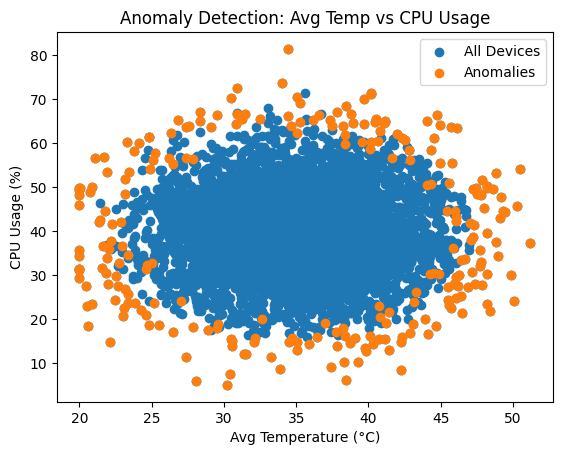

In [6]:
plt.figure()
plt.scatter(df["avg_temp"], df["cpu_usage"], label="All Devices")
plt.scatter(anomalies["avg_temp"], anomalies["cpu_usage"], label="Anomalies")
plt.title("Anomaly Detection: Avg Temp vs CPU Usage")
plt.xlabel("Avg Temperature (°C)")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.show()

## Save Results
We save anomaly outputs so we can use them later in:
- Streamlit dashboard
- GenAI explanation engine
- Reporting / monitoring

In [7]:
OUT_PATH = Path("../data/processed")
OUT_PATH.mkdir(parents=True, exist_ok=True)

df.to_csv(OUT_PATH / "telemetry_with_anomalies.csv", index=False)
print("Saved:", OUT_PATH / "telemetry_with_anomalies.csv")

Saved: ../data/processed/telemetry_with_anomalies.csv


## Business Insight

- ~5% of devices exhibit abnormal stress behavior.
- 84 devices show overheating-risk patterns (>42°C).
- These devices may experience:
  - Faster battery degradation
  - Performance throttling
  - Increased hardware failure probability

This anomaly module can help:
- Proactively notify users
- Reduce unexpected device shutdowns
- Lower service center workload